In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from xhistogram.xarray import histogram as xhist

In [2]:
ds = xr.open_dataset("../data/SV_gridParticles.zarr")
ds

<xarray.Dataset> Size: 4GB
Dimensions:     (trajectory: 750000, obs: 240)
Coordinates:
  * trajectory  (trajectory) int64 6MB 0 1 2 3 4 ... 749996 749997 749998 749999
  * obs         (obs) int32 960B 0 1 2 3 4 5 6 7 ... 233 234 235 236 237 238 239
Data variables:
    lat         (trajectory, obs) float32 720MB ...
    lon         (trajectory, obs) float32 720MB ...
    time        (trajectory, obs) datetime64[ns] 1GB ...
    z           (trajectory, obs) float32 720MB ...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4CheckOutOfBounds
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [3]:
lon_diff_zero = ds.lon.diff(dim="obs").isel(obs=0) == 0
lat_diff_zero = ds.lat.diff(dim="obs").isel(obs=0) == 0
stuck = (lon_diff_zero & lat_diff_zero).squeeze().compute()

In [5]:
ds_clean = ds.isel(trajectory=~stuck.values)
ds_clean

<xarray.Dataset> Size: 4GB
Dimensions:     (trajectory: 749998, obs: 240)
Coordinates:
  * trajectory  (trajectory) int64 6MB 0 1 2 3 4 ... 749996 749997 749998 749999
  * obs         (obs) int32 960B 0 1 2 3 4 5 6 7 ... 233 234 235 236 237 238 239
Data variables:
    lat         (trajectory, obs) float32 720MB ...
    lon         (trajectory, obs) float32 720MB ...
    time        (trajectory, obs) datetime64[ns] 1GB ...
    z           (trajectory, obs) float32 720MB ...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4CheckOutOfBounds
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [6]:
bin_width = 0.01

lon_min = float(ds_clean.lon.min())
lon_max = float(ds_clean.lon.max())
lat_min = float(ds_clean.lat.min())
lat_max = float(ds_clean.lat.max())

lon_bins = np.arange(lon_min, lon_max + bin_width, bin_width)
lat_bins = np.arange(lat_min, lat_max + bin_width, bin_width)

In [7]:
obs_counts = xhist(
    ds_clean.lon, ds_clean.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory", ],
    bin_dim_suffix=""
)

obs_counts

<xarray.DataArray 'histogram_lon_lat' (obs: 240, lon: 157, lat: 123)> Size: 37MB
array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0, 210, ...,   0,   0,   0],
        [  0,   0, 160, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0, 272, ...,   0,   0,   0],
        [  0,   0, 112, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
...
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]]], shape=(240, 157, 123))
Coordinates:
  * obs      (obs) int32 960B 0 1 2 3 4 5 6 7 ... 233 234 235 236 237 238 239
  * lon      (lon) float64 1kB -26.39 -26.38 -26.37 ... -24.85 -24.84 -24.83
  * lat      (lat) float64 984B 16.68 16.69 16.7 16.71 ... 17.88 17.89 17.9

In [8]:
obs_counts.to_netcdf("012_heatmaps.nc")

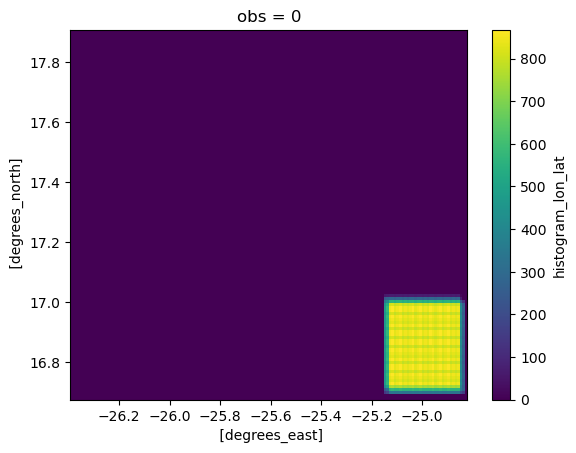

In [9]:
obs_counts.isel(obs=0).plot(x="lon", y="lat")

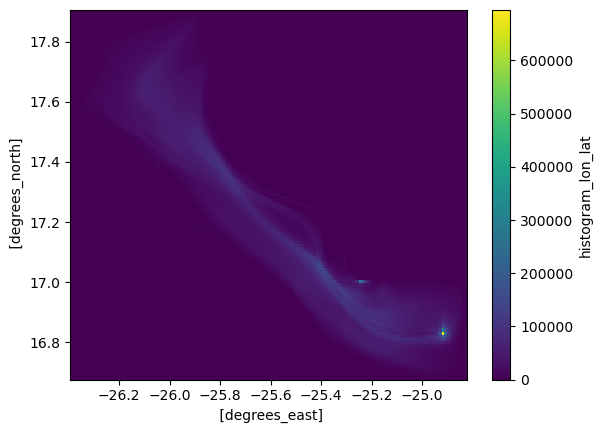

In [10]:
obs_counts.pad(obs=(0, 1), constant_values=0).coarsen(obs=10, boundary="trim").sum().sum(dim="obs").plot(x="lon", y="lat")

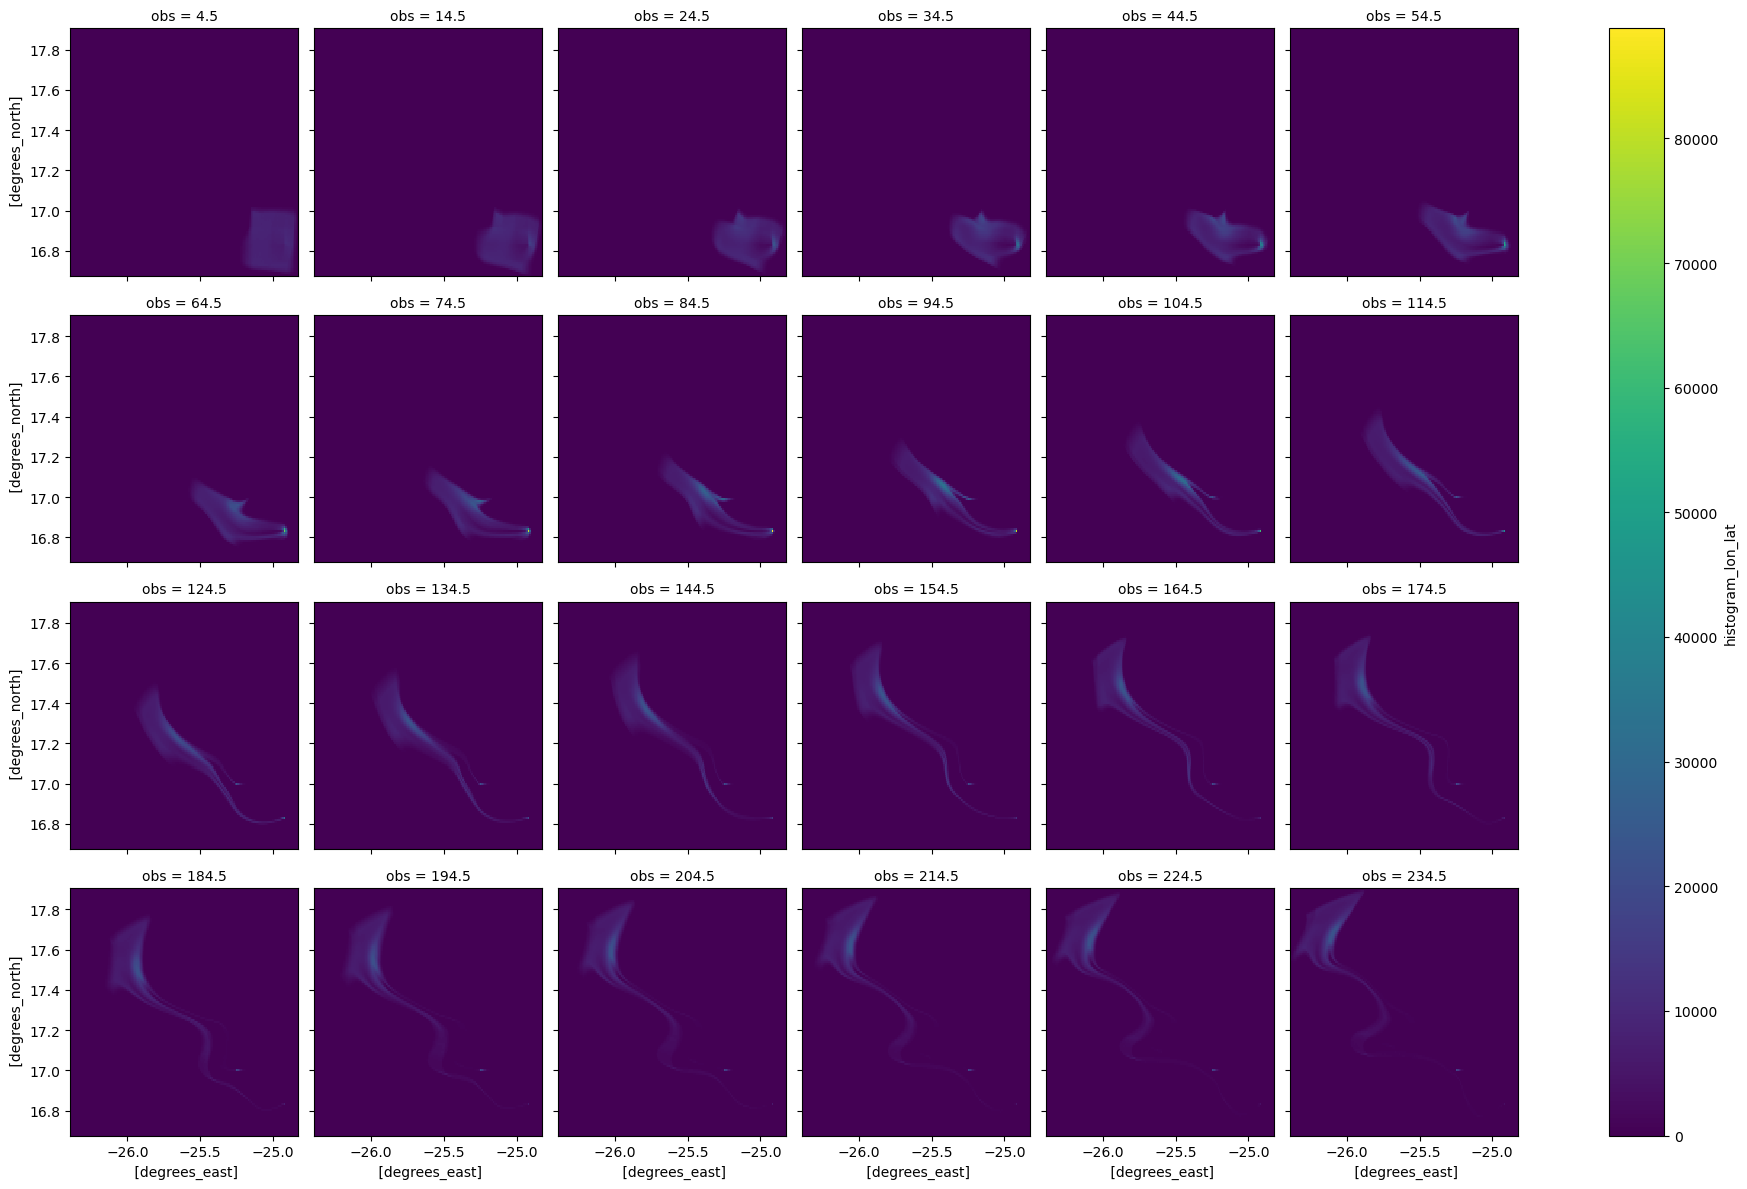

In [11]:
obs_counts.pad(obs=(0, 1), constant_values=0).coarsen(obs=10, boundary="trim").sum().plot(col="obs", col_wrap=6, x="lon", y="lat")